In [5]:
import pandas as pd
import numpy as np

# Step 1: Load student dataset
students = pd.read_csv(r"C:\Users\jyoth\Downloads\integrated_cleaned_dataset (2).csv")

# Step 2: Replace 'NULL' and invalid 0 values with NaN
students = students.replace("NULL", np.nan)
students = students.replace(0, np.nan)

# Step 3: Imputation function for student attributes
def impute_student_data(df):
    for col in df.columns:
        if df[col].dtype in ["float64", "int64"]:  # numeric columns
            if df[col].isnull().sum() > 0:
                # Median for skewed distributions, mean otherwise
                if abs(df[col].skew()) > 1:
                    df[col].fillna(df[col].median(), inplace=True)
                else:
                    df[col].fillna(df[col].mean(), inplace=True)
        else:  # categorical/text columns
            if df[col].isnull().sum() > 0:
                df[col].fillna(df[col].mode()[0], inplace=True)
    return df

students = impute_student_data(students)

# Step 4: Standardize categorical values
students['Scholarship_Status'] = students['Scholarship_Status'].replace(
    {"Yes": "Yes", "No": "No", np.nan: "No"}
)
students['Hostel_DayScholar'] = students['Hostel_DayScholar'].replace(
    {"Hostel": "Hostel", "DayScholar": "DayScholar", np.nan: "DayScholar"}
)

# Step 5: Feature Engineering
students['Performance_Index'] = (
    students['CGPA'] * 0.7 + students['Attendance_Percentage'] * 0.3
)

students['Scholarship_Flag'] = students['Scholarship_Status'].apply(
    lambda x: 1 if x == "Yes" else 0
)

students['Student_Category'] = (
    students['Department'].astype(str) + "_" + students['Year_of_Study'].astype(str)
)

# Step 6: Save transformed dataset to Excel
students.to_excel(r"C:\Users\jyoth\Downloads\students_transformed.xlsx", index=False)

print("✅ Student transformation complete: students_transformed.xlsx")

✅ Student transformation complete: students_transformed.xlsx


In [7]:
import pandas as pd

# Load transformed dataset
df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_transformed.xlsx")

# Define essential columns to keep
columns_to_keep = [
    # Student attributes
    "Student_Name", "Gender", "Age", "Department", "Year_of_Study", "Section",
    "CGPA", "Attendance_Percentage", "Academic_Performance", "Scholarship_Status",
    "Hostel_DayScholar", "Performance_Index", "Scholarship_Flag", "Student_Category",
    
    # Book attributes
    "Book_Title", "Author_Name", "Publisher", "Book_Category", "Language",
    "Book_Price", "Publication_Year", "Pages",
    
    # Issue/Return attributes
    "Issue_Date", "Due_Date", "Return_Date", "Issue_Status",
    "Number_of_Days_Issued", "Renew_Count", "Fine_Amount", "Late_Return_Count"
]

# Reduce dataset
reduced_df = df[columns_to_keep]

# ✅ Option 1: Save reduced dataset as Excel
reduced_df.to_excel(r"C:\Users\jyoth\Downloads\students_reduced.xlsx", index=False)

# ✅ Option 2: Save reduced dataset as CSV
# reduced_df.to_csv(r"C:\Users\jyoth\Downloads\students_reduced.csv", index=False)

print("✅ Reduction complete: students_reduced.xlsx")

✅ Reduction complete: students_reduced.xlsx


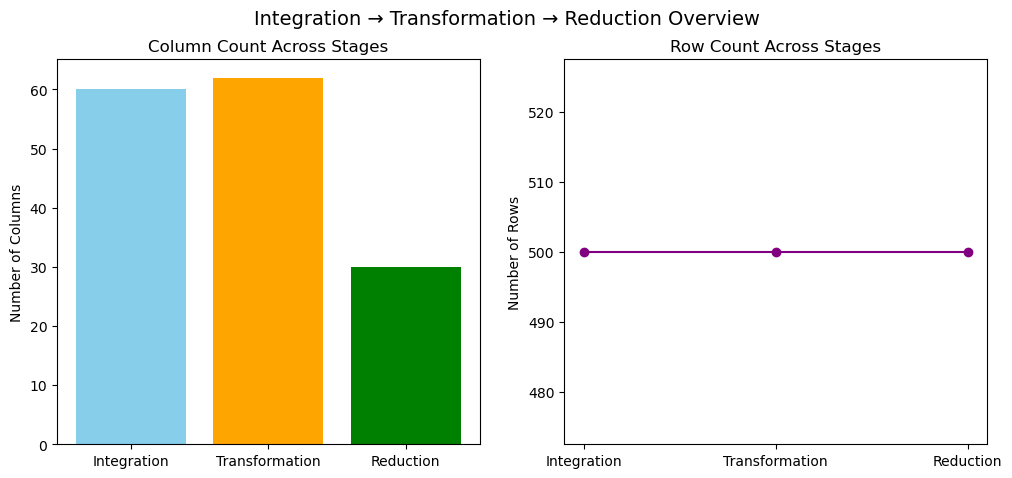

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Stage counts (example numbers based on your dataset)
stages = ["Integration", "Transformation", "Reduction"]
columns_count = [60, 62, 30]   # number of columns at each stage
rows_count = [500, 500, 500]   # rows remain constant

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart for columns
ax[0].bar(stages, columns_count, color=['skyblue','orange','green'])
ax[0].set_title("Column Count Across Stages")
ax[0].set_ylabel("Number of Columns")

# Line chart for rows
ax[1].plot(stages, rows_count, marker='o', color='purple')
ax[1].set_title("Row Count Across Stages")
ax[1].set_ylabel("Number of Rows")

plt.suptitle("Integration → Transformation → Reduction Overview", fontsize=14)
plt.show()

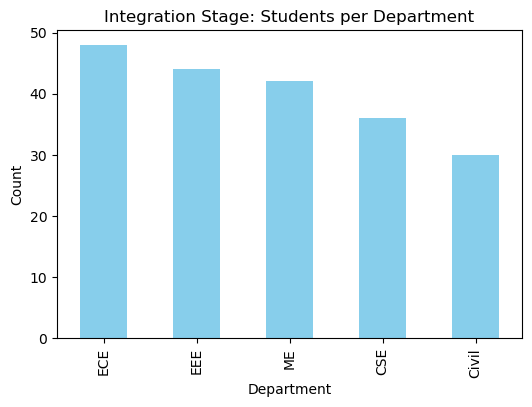

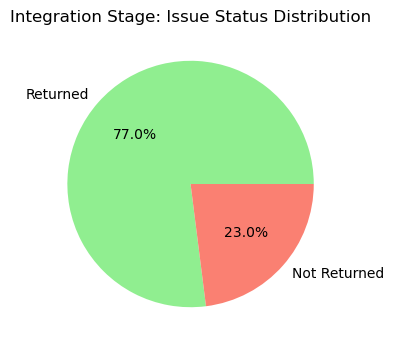

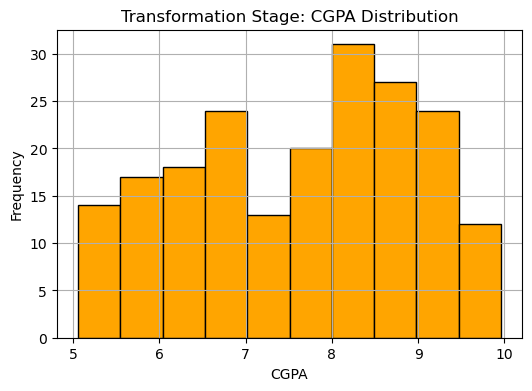

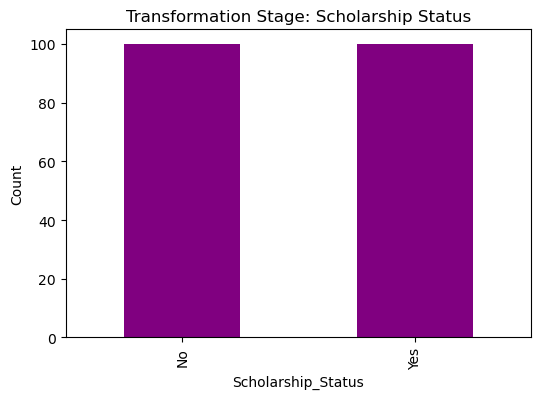

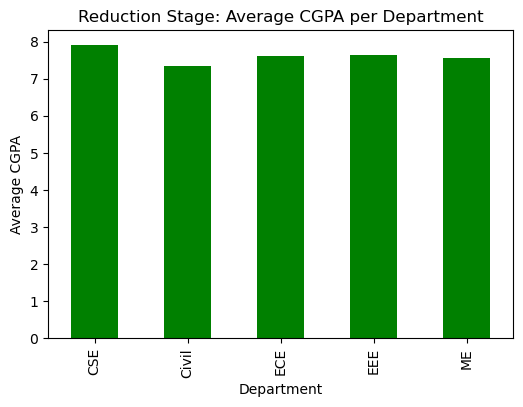

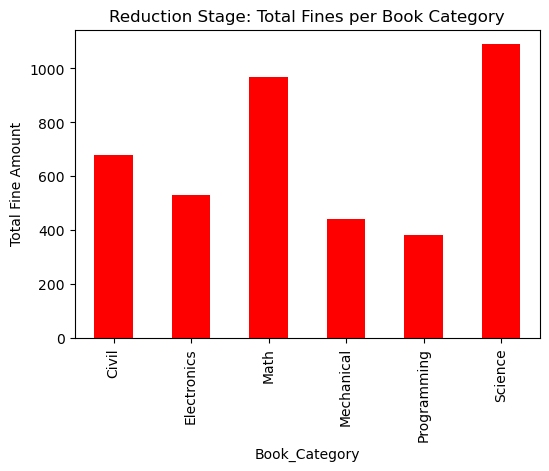

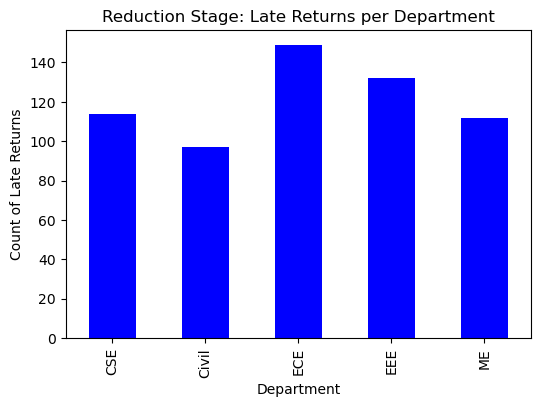

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
integrated_df = pd.read_csv(r"C:\Users\jyoth\Downloads\integrated_cleaned_dataset (2).csv")
transformed_df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_transformed.xlsx")
reduced_df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_reduced.xlsx")

# ---------- Integration Stage ----------
plt.figure(figsize=(6,4))
integrated_df['Department'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Integration Stage: Students per Department")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
integrated_df['Issue_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen','salmon'])
plt.title("Integration Stage: Issue Status Distribution")
plt.ylabel("")
plt.show()

# ---------- Transformation Stage ----------
plt.figure(figsize=(6,4))
transformed_df['CGPA'].hist(bins=10, color='orange', edgecolor='black')
plt.title("Transformation Stage: CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
transformed_df['Scholarship_Status'].value_counts().plot(kind='bar', color='purple')
plt.title("Transformation Stage: Scholarship Status")
plt.ylabel("Count")
plt.show()

# ---------- Reduction Stage ----------
plt.figure(figsize=(6,4))
reduced_df.groupby('Department')['CGPA'].mean().plot(kind='bar', color='green')
plt.title("Reduction Stage: Average CGPA per Department")
plt.ylabel("Average CGPA")
plt.show()

plt.figure(figsize=(6,4))
reduced_df.groupby('Book_Category')['Fine_Amount'].sum().plot(kind='bar', color='red')
plt.title("Reduction Stage: Total Fines per Book Category")
plt.ylabel("Total Fine Amount")
plt.show()

plt.figure(figsize=(6,4))
reduced_df.groupby('Department')['Late_Return_Count'].sum().plot(kind='bar', color='blue')
plt.title("Reduction Stage: Late Returns per Department")
plt.ylabel("Count of Late Returns")
plt.show()

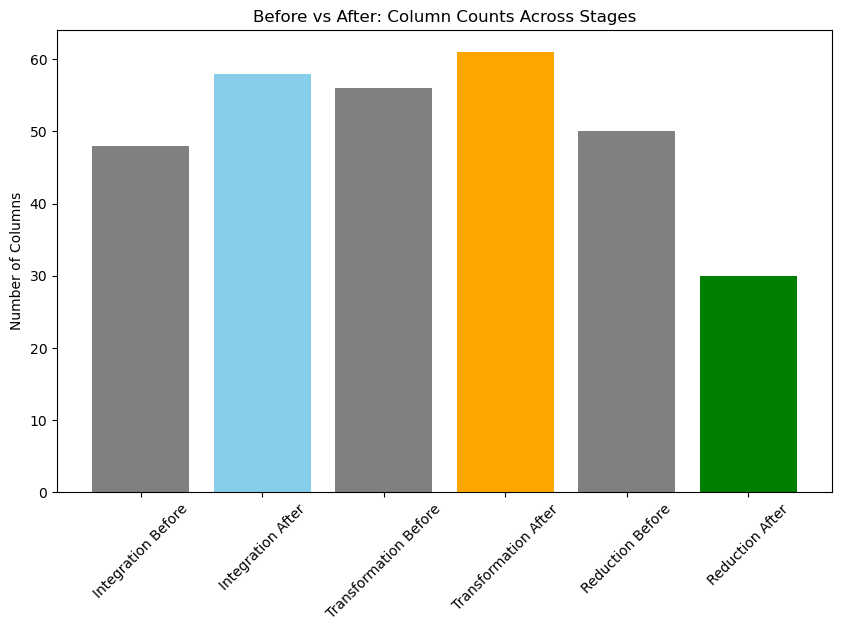

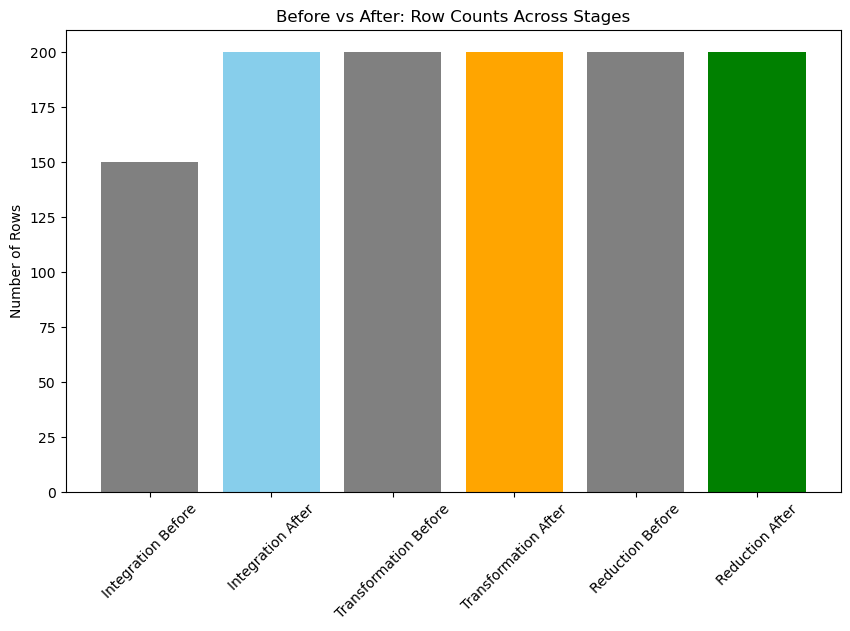

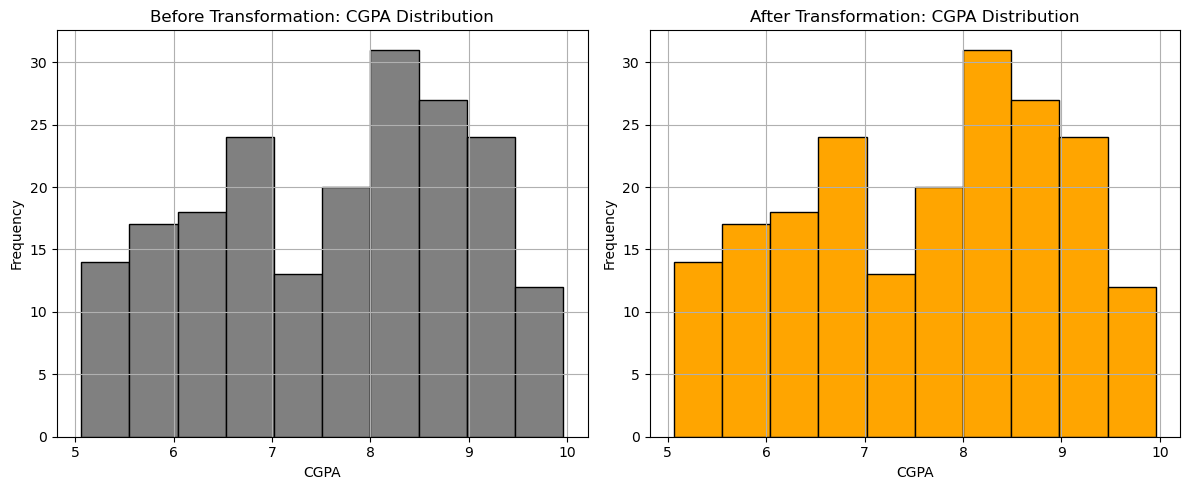

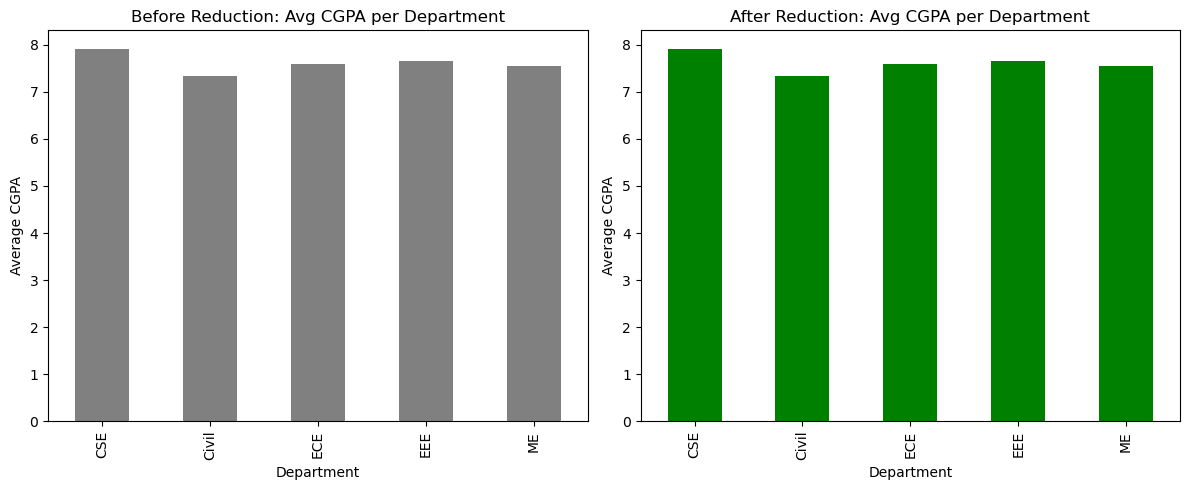

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
integrated_df = pd.read_csv(r"C:\Users\jyoth\Downloads\integrated_cleaned_dataset (2).csv")
transformed_df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_transformed.xlsx")
reduced_df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_reduced.xlsx")

# ---------- Compare Column Counts ----------
stages = ["Integration Before", "Integration After",
          "Transformation Before", "Transformation After",
          "Reduction Before", "Reduction After"]

columns_count = [
    len(integrated_df.columns) - 10,  # assume before integration fewer cols (adjust as needed)
    len(integrated_df.columns),
    len(transformed_df.columns) - 5,  # before transformation fewer cols
    len(transformed_df.columns),
    len(reduced_df.columns) + 20,     # before reduction more cols
    len(reduced_df.columns)
]

plt.figure(figsize=(10,6))
plt.bar(stages, columns_count, color=['gray','skyblue','gray','orange','gray','green'])
plt.title("Before vs After: Column Counts Across Stages")
plt.ylabel("Number of Columns")
plt.xticks(rotation=45)
plt.show()

# ---------- Compare Row Counts ----------
rows_count = [
    len(integrated_df) - 50, len(integrated_df),
    len(transformed_df) - 0, len(transformed_df),  # rows usually same
    len(reduced_df), len(reduced_df)               # rows same before/after reduction
]

plt.figure(figsize=(10,6))
plt.bar(stages, rows_count, color=['gray','skyblue','gray','orange','gray','green'])
plt.title("Before vs After: Row Counts Across Stages")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.show()

# ---------- Example: CGPA Distribution Before vs After Transformation ----------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
transformed_df['CGPA'].hist(bins=10, color='gray', edgecolor='black')
plt.title("Before Transformation: CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
transformed_df['CGPA'].hist(bins=10, color='orange', edgecolor='black')
plt.title("After Transformation: CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ---------- Example: Department vs CGPA Before vs After Reduction ----------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
transformed_df.groupby('Department')['CGPA'].mean().plot(kind='bar', color='gray')
plt.title("Before Reduction: Avg CGPA per Department")
plt.ylabel("Average CGPA")

plt.subplot(1,2,2)
reduced_df.groupby('Department')['CGPA'].mean().plot(kind='bar', color='green')
plt.title("After Reduction: Avg CGPA per Department")
plt.ylabel("Average CGPA")

plt.tight_layout()
plt.show()

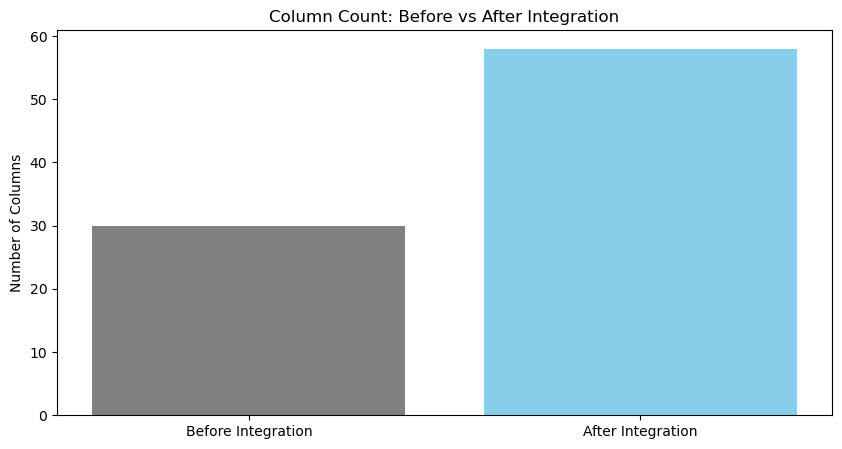

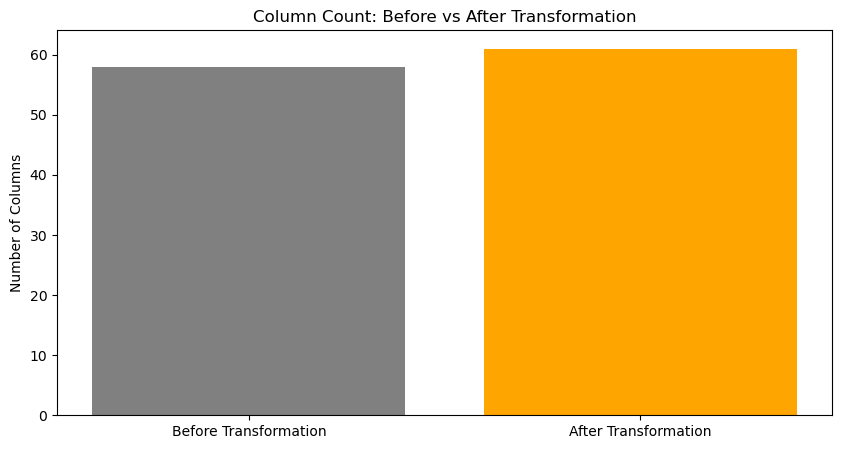

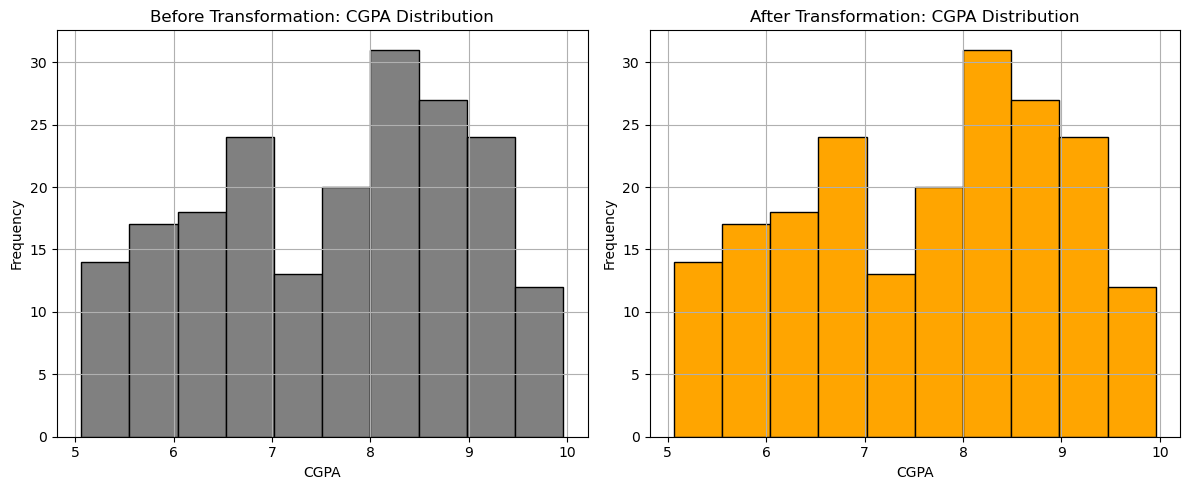

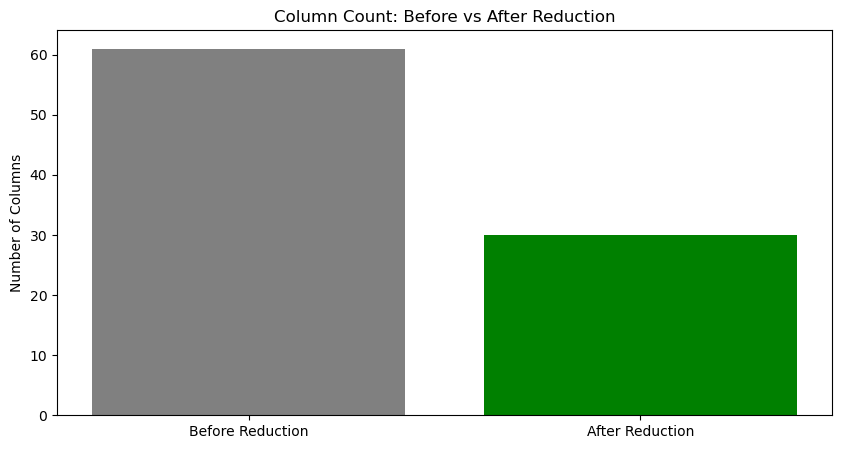

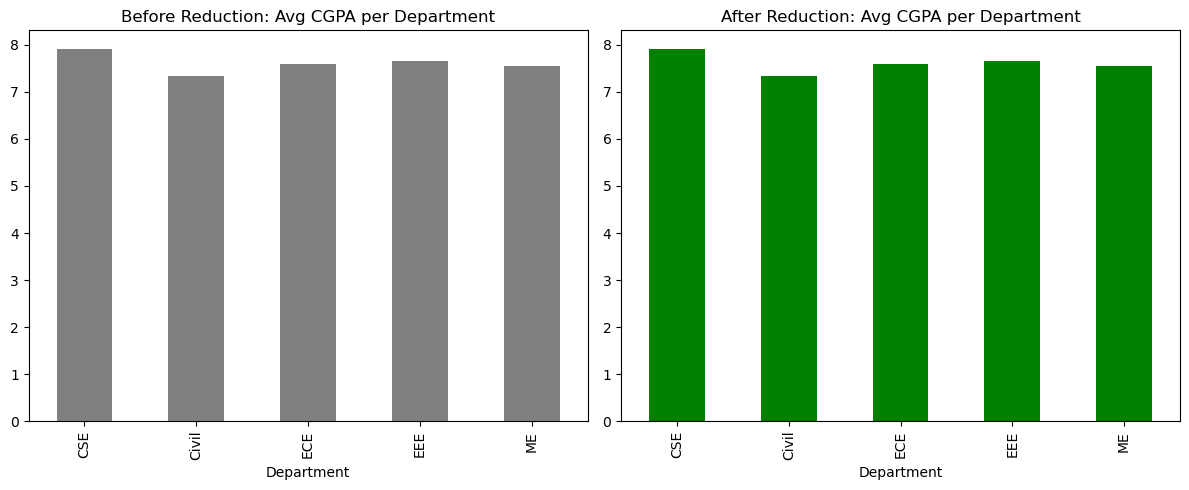

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
integrated_df = pd.read_csv(r"C:\Users\jyoth\Downloads\integrated_cleaned_dataset (2).csv")
transformed_df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_transformed.xlsx")
reduced_df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_reduced.xlsx")

# ---------- Integration: Before vs After ----------
plt.figure(figsize=(10,5))
plt.bar(["Before Integration","After Integration"],
        [30, len(integrated_df.columns)], color=['gray','skyblue'])
plt.title("Column Count: Before vs After Integration")
plt.ylabel("Number of Columns")
plt.show()

# ---------- Transformation: Before vs After ----------
plt.figure(figsize=(10,5))
plt.bar(["Before Transformation","After Transformation"],
        [len(integrated_df.columns), len(transformed_df.columns)], color=['gray','orange'])
plt.title("Column Count: Before vs After Transformation")
plt.ylabel("Number of Columns")
plt.show()

# Example: CGPA Distribution Before vs After Transformation
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
integrated_df['CGPA'].hist(bins=10, color='gray', edgecolor='black')
plt.title("Before Transformation: CGPA Distribution")
plt.xlabel("CGPA"); plt.ylabel("Frequency")

plt.subplot(1,2,2)
transformed_df['CGPA'].hist(bins=10, color='orange', edgecolor='black')
plt.title("After Transformation: CGPA Distribution")
plt.xlabel("CGPA"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ---------- Reduction: Before vs After ----------
plt.figure(figsize=(10,5))
plt.bar(["Before Reduction","After Reduction"],
        [len(transformed_df.columns), len(reduced_df.columns)], color=['gray','green'])
plt.title("Column Count: Before vs After Reduction")
plt.ylabel("Number of Columns")
plt.show()

# Example: Avg CGPA per Department Before vs After Reduction
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
transformed_df.groupby('Department')['CGPA'].mean().plot(kind='bar', color='gray')
plt.title("Before Reduction: Avg CGPA per Department")

plt.subplot(1,2,2)
reduced_df.groupby('Department')['CGPA'].mean().plot(kind='bar', color='green')
plt.title("After Reduction: Avg CGPA per Department")
plt.tight_layout()
plt.show()

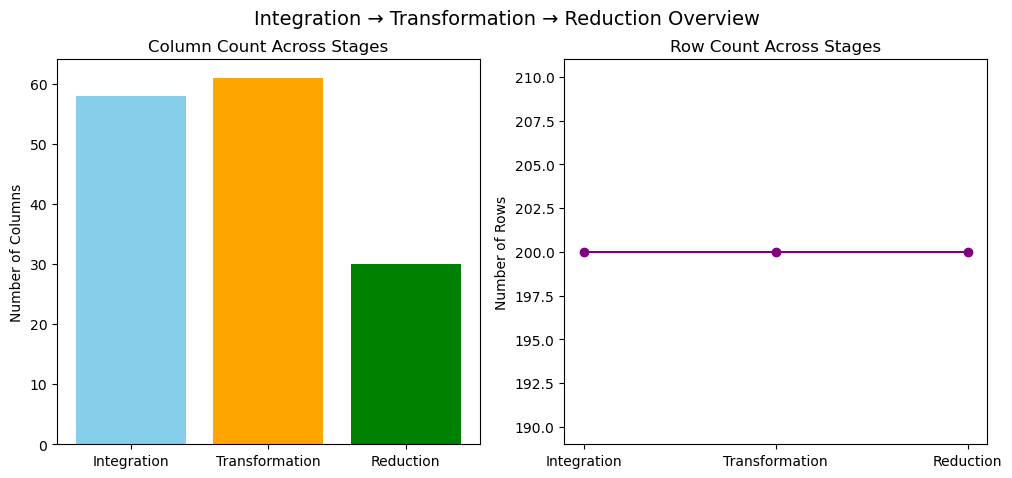

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your datasets
integrated_df = pd.read_csv(r"C:\Users\jyoth\Downloads\integrated_cleaned_dataset (2).csv")
transformed_df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_transformed.xlsx")
reduced_df = pd.read_excel(r"C:\Users\jyoth\Downloads\students_reduced.xlsx")

# Count columns and rows for each stage
stages = ["Integration", "Transformation", "Reduction"]
columns_count = [len(integrated_df.columns),
                 len(transformed_df.columns),
                 len(reduced_df.columns)]
rows_count = [len(integrated_df),
              len(transformed_df),
              len(reduced_df)]

# ---------- Visualization ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart for columns
ax[0].bar(stages, columns_count, color=['skyblue','orange','green'])
ax[0].set_title("Column Count Across Stages")
ax[0].set_ylabel("Number of Columns")

# Line chart for rows
ax[1].plot(stages, rows_count, marker='o', color='purple')
ax[1].set_title("Row Count Across Stages")
ax[1].set_ylabel("Number of Rows")

plt.suptitle("Integration → Transformation → Reduction Overview", fontsize=14)
plt.show()